# Linear Regression Training Pipeline

This notebook implements an end-to-end Linear Regression training pipeline with:
- Data loading and exploration
- Preprocessing and scaling
- Train-test split
- Model training
- Hyperparameter tuning with Optuna
- Model evaluation and validation

## 1. Import Required Libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import joblib

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score
from sklearn.impute import SimpleImputer

# Mute warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


## 2. Load and Explore Dataset

In [38]:
DATA_PATH = '../../data/typhoon_impact_with_extreme_weather.csv' 

# --- LEAD DEVELOPER CONFIGURATION ---
INPUT_FEATURES = [
    'max_sustained_wind_kph',
    'typhoon_type',
    'max_24hr_rainfall_mm',
    'total_storm_rainfall_mm',
    'min_pressure_hpa'
]

# Mapping Intensity (Ordinal is better for Linear Regression)
TYPHOON_TYPE_MAPPING = {
    'TD': 0,   # Tropical Depression
    'TS': 1,   # Tropical Storm
    'STS': 2,  # Severe Tropical Storm
    'TY': 3,   # Typhoon
    'STY': 4   # Super Typhoon
}
# ------------------------------------

try:
    df = pd.read_csv(DATA_PATH)
    
    # Normalize Column Names
    df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('/', '_')
    
    # Target Selection
    TARGET_COLUMN = 'cost' 

    print(f"✅ Data Loaded. Shape: {df.shape}")
    print(f"🎯 Target Column: {TARGET_COLUMN}")
    
    # Drop rows where target is missing
    df = df.dropna(subset=[TARGET_COLUMN])
    
    # Check for Zero-Inflation
    zeros = (df[TARGET_COLUMN] == 0).sum()
    print(f"   Zero-Cost Events: {zeros} ({zeros/len(df):.1%})")

except Exception as e:
    print(f"❌ Error: {e}")

✅ Data Loaded. Shape: (1776, 30)
🎯 Target Column: cost
   Zero-Cost Events: 1333 (75.1%)


## 3. Data Preprocessing

In [42]:
X = df[INPUT_FEATURES].copy()
y = df[TARGET_COLUMN].copy()

# 1. Apply Lead Dev's Ordinal Encoding
# We convert "TY", "TS" directly to numbers 0-4.
# Ensure values are uppercase to match the mapping keys.
X['typhoon_type'] = X['typhoon_type'].astype(str).str.upper().map(TYPHOON_TYPE_MAPPING)

# Safety Check: If mapping created NaNs (e.g., unknown type), fill with median mode (usually 1 or 2)
if X['typhoon_type'].isnull().any():
    print("⚠️ Warning: Some typhoon types didn't match the mapping. Filling with mode.")
    X['typhoon_type'] = X['typhoon_type'].fillna(X['typhoon_type'].median())

# 2. Add Physics Features (Crucial for Linear Models)
X['wind_power'] = X['max_sustained_wind_kph'] ** 3 
X['rain_wind_combo'] = X['max_24hr_rainfall_mm'] * X['max_sustained_wind_kph']
X['pressure_drop'] = 1013 - X['min_pressure_hpa']

# 3. Handle Missing Values
imputer = SimpleImputer(strategy='median')
X_imputed_array = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed_array, columns=X.columns, index=X.index)

print("✅ Preprocessing Complete (Ordinal Encoding Applied).")
print(X_imputed.head())

✅ Preprocessing Complete (Ordinal Encoding Applied).
   max_sustained_wind_kph  typhoon_type  max_24hr_rainfall_mm  \
0                   195.0           4.0                  25.6   
1                   195.0           4.0                  20.3   
2                   195.0           4.0                  25.6   
3                   195.0           4.0                  25.6   
4                   195.0           4.0                  25.6   

   total_storm_rainfall_mm  min_pressure_hpa  wind_power  rain_wind_combo  \
0                    39.00             977.1   7414875.0           4992.0   
1                    32.71            1000.5   7414875.0           3958.5   
2                    39.00             977.1   7414875.0           4992.0   
3                    39.00             977.1   7414875.0           4992.0   
4                    39.00             977.1   7414875.0           4992.0   

   pressure_drop  
0           35.9  
1           12.5  
2           35.9  
3           35.9 

## Benchmark

In [30]:
def run_benchmark(target_name):
    """
    Runs the full pipeline (Split -> Scale -> Tune -> Evaluate) for a specific target.
    Returns the performance metrics.
    """
    print(f"\nProcessing Target: {target_name.upper()}...")
    
    # 1. Check if target exists
    if target_name not in df.columns:
        print(f"   ⚠️ Target '{target_name}' not found. Skipping.")
        return None

    y = df[target_name]
    
    # STEP 4: Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X_global, y, test_size=0.2, random_state=42)
    
    # STEP 5: Feature Scaling
    scaler = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # STEP 6: Basic Linear Regression (Baseline)
    base_model = LinearRegression()
    base_model.fit(X_train_scaled, y_train)
    y_pred_base = base_model.predict(X_test_scaled)
    y_pred_base = np.maximum(y_pred_base, 0) # Clamp to 0
    base_r2 = r2_score(y_test, y_pred_base)
    
    # STEP 7: Hyperparameter Tuning (Optuna)
    def objective(trial):
        model_type = trial.suggest_categorical('model_type', ['linear', 'ridge', 'lasso'])
        if model_type == 'linear':
            model = LinearRegression(fit_intercept=trial.suggest_categorical('fit_int', [True, False]))
        elif model_type == 'ridge':
            model = Ridge(alpha=trial.suggest_float('alpha', 0.01, 10.0, log=True), random_state=42)
        else:
            model = Lasso(alpha=trial.suggest_float('alpha', 0.01, 10.0, log=True), random_state=42)
        return cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='r2').mean()

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=15) # Fast tuning
    
    # STEP 8: Retrieve Best Params
    best = study.best_params
    
    # STEP 9: Final Model Evaluation
    if best['model_type'] == 'linear': final_model = LinearRegression(fit_intercept=best['fit_int'])
    elif best['model_type'] == 'ridge': final_model = Ridge(alpha=best['alpha'], random_state=42)
    else: final_model = Lasso(alpha=best['alpha'], random_state=42)
        
    final_model.fit(X_train_scaled, y_train)
    y_pred_final = final_model.predict(X_test_scaled)
    y_pred_final = np.maximum(y_pred_final, 0) # Clamp to 0
    
    final_r2 = r2_score(y_test, y_pred_final)
    final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
    
    return {
        'Target': target_name,
        'Baseline R2': base_r2,
        'Final R2': final_r2,
        'RMSE': final_rmse,
        'Best Model': best['model_type'].upper(),
        'Improvement': final_r2 - base_r2
    }

print("✅ Benchmarking Engine Ready.")

✅ Benchmarking Engine Ready.


In [31]:
results = []

print(f"🚀 Starting Benchmark for {len(TARGET_LIST)} targets...")

for target in TARGET_LIST:
    res = run_benchmark(target)
    if res:
        results.append(res)

print("\n✅ Benchmarking Complete.")

NameError: name 'TARGET_LIST' is not defined

--- 🏆 MODEL PERFORMANCE LEADERBOARD ---


,Target,Baseline R2,Final R2,RMSE,Best Model,Improvement
5,totally,0.352227,0.350367,2.862019e+02,RIDGE,-0.001860
2,brgy,0.162357,0.159659,1.109370e+01,LASSO,-0.002697
4,partially,0.155038,0.153989,1.194650e+03,LASSO,-0.001049
3,cost,0.131150,0.130942,1.089356e+06,RIDGE,-0.000208
0,families,0.050969,0.050275,4.316305e+03,LASSO,-0.000694
1,person,0.048357,0.048145,1.702057e+04,RIDGE,-0.000212


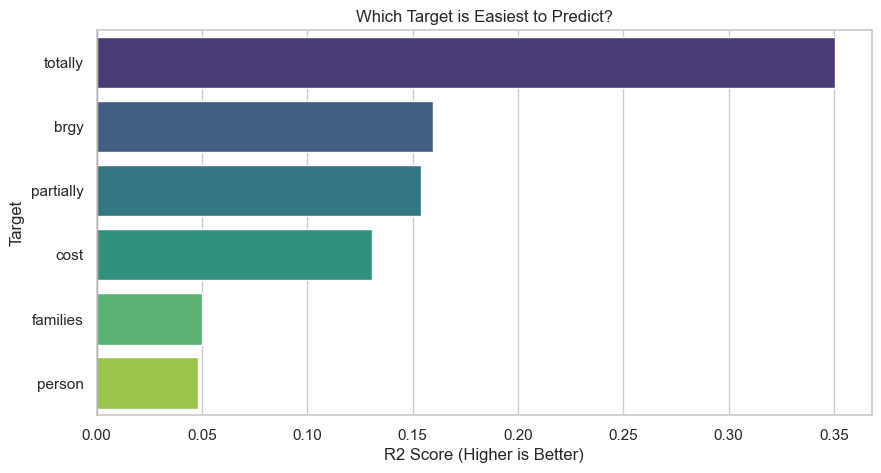

In [ ]:
# Convert results to DataFrame
leaderboard = pd.DataFrame(results)

# Sort by best Accuracy (R2 Score)
leaderboard = leaderboard.sort_values(by='Final R2', ascending=False)

print("--- 🏆 MODEL PERFORMANCE LEADERBOARD ---")
display(leaderboard)

# Quick Visualization
plt.figure(figsize=(10, 5))
sns.barplot(data=leaderboard, x='Final R2', y='Target', palette='viridis')
plt.title('Which Target is Easiest to Predict?')
plt.xlabel('R2 Score (Higher is Better)')
plt.axvline(0, color='black')
plt.show()

🔍 Deep Dive into Best Target: TOTALLY


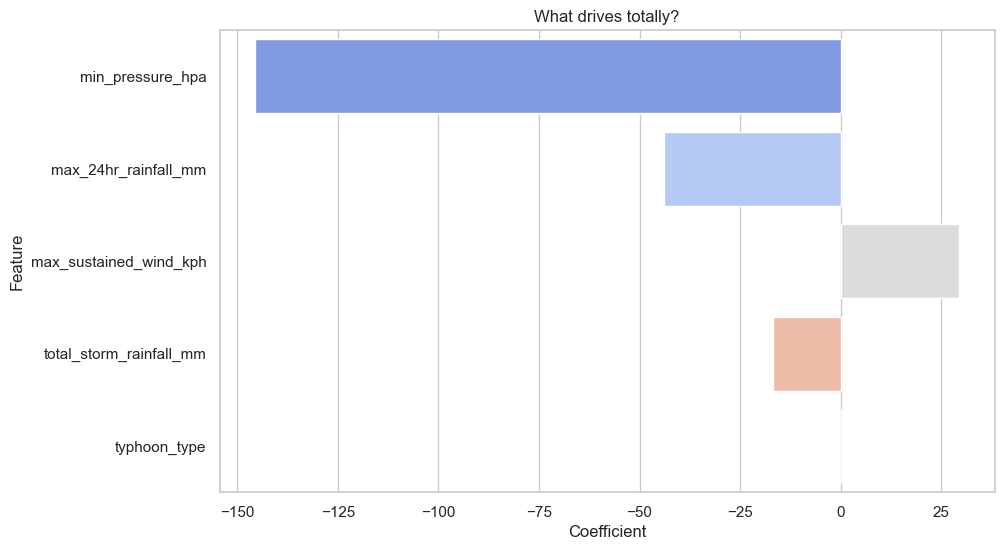

In [ ]:
# Select the best performing target automatically
best_target = leaderboard.iloc[0]['Target']
print(f"🔍 Deep Dive into Best Target: {best_target.upper()}")

# Re-train just this one to see coefficients
# (We define this mini-block just for visualization)
y_best = df[best_target]
scaler = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
X_sc = scaler.fit_transform(X_global)
model = Ridge() # Defaulting to Ridge for quick inspection
model.fit(X_sc, y_best)

# Feature Importance
coef_df = pd.DataFrame({'Feature': INPUT_FEATURES, 'Coefficient': model.coef_})
coef_df['Abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs', ascending=False)

sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')
plt.title(f'What drives {best_target}?')
plt.show()

## 4. Train-Test Split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

print(f"Data Split Complete.")
print(f"Training Rows: {len(X_train)}")
print(f"Testing Rows:  {len(X_test)}")

Data Split Complete.
Training Rows: 1420
Testing Rows:  356


## 5. Feature Scaling

In [44]:
scaler = StandardScaler()

X_train_sc_array = scaler.fit_transform(X_train)
X_test_sc_array = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_sc_array, columns=X_train.columns, index=X_train.index 
)
X_test_scaled = pd.DataFrame(
    X_test_sc_array, columns=X_test.columns, index=X_test.index
)

print("Data Scaled.")

Data Scaled.


## 6. Basic Linear Regression Model Training

In [45]:
print("Training Stage 1 (Logistic Regression)...")

y_train_class = (y_train > 0).astype(int)

# Logistic Regression is the Linear standard for classification
baseline_clf = LogisticRegression(
    class_weight='balanced', 
    random_state=42
)
baseline_clf.fit(X_train_scaled, y_train_class)

print("Classifier Trained.")

Training Stage 1 (Logistic Regression)...
Classifier Trained.


## 7. Hyperparameter Tuning with Optuna

In [46]:
mask_nonzero = y_train > 0
X_train_nonzero = X_train_scaled[mask_nonzero]
y_train_nonzero = y_train[mask_nonzero]

def objective(trial):
    # Tune Alpha (Regularization Strength)
    alpha = trial.suggest_float('alpha', 0.1, 100.0, log=True)
    
    model = Ridge(alpha=alpha, random_state=42)
    
    scores = cross_val_score(
        model, 
        X_train_nonzero, 
        y_train_nonzero, 
        cv=3, 
        scoring='neg_mean_absolute_error'
    )
    return scores.mean()

print("⏳ Starting Optuna Tuning...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print("✅ Tuning Complete.")

[I 2025-12-11 13:33:14,328] A new study created in memory with name: no-name-8f17939b-494c-4030-b725-a4b51246fb25
[I 2025-12-11 13:33:14,339] Trial 0 finished with value: -1275843.15935866 and parameters: {'alpha': 0.9536473484242707}. Best is trial 0 with value: -1275843.15935866.
[I 2025-12-11 13:33:14,350] Trial 1 finished with value: -1274654.4954077434 and parameters: {'alpha': 1.3738554489050137}. Best is trial 1 with value: -1274654.4954077434.
[I 2025-12-11 13:33:14,359] Trial 2 finished with value: -1276332.0158625487 and parameters: {'alpha': 0.7783341807905579}. Best is trial 1 with value: -1274654.4954077434.
[I 2025-12-11 13:33:14,368] Trial 3 finished with value: -1268533.9798632497 and parameters: {'alpha': 22.213577653325643}. Best is trial 3 with value: -1268533.9798632497.
[I 2025-12-11 13:33:14,376] Trial 4 finished with value: -1274391.5174842179 and parameters: {'alpha': 36.308405598636554}. Best is trial 3 with value: -1268533.9798632497.
[I 2025-12-11 13:33:14,38

⏳ Starting Optuna Tuning...
✅ Tuning Complete.


In [47]:
print("Best Hyperparameters (Alpha):")
print(study.best_params)
best_params = study.best_params

Best Hyperparameters (Alpha):
{'alpha': 11.511861664455683}


## 8. Model Evaluation and Validation

In [53]:
# 1. Train Final Linear Regressor (Ridge)
final_reg = Ridge(**best_params, random_state=42)
final_reg.fit(X_train_nonzero, y_train_nonzero)

# 2. Make Predictions
# Step A: Get Probabilities (Logistic)
probs = baseline_clf.predict_proba(X_test_scaled)[:, 1]

# Step B: Apply Threshold (0.40)
CUSTOM_THRESHOLD = 0.35 
pred_is_damage = (probs >= CUSTOM_THRESHOLD).astype(int)

# Step C: Predict Amount (Ridge)
pred_amount = final_reg.predict(X_test_scaled)
# Force negatives to 0 (Linear Regression quirk)
pred_amount = np.maximum(pred_amount, 0) 

# Step D: Combine
final_predictions = pred_is_damage * pred_amount

# 3. Calculate Metrics
acc = accuracy_score((y_test > 0).astype(int), pred_is_damage)
mae = mean_absolute_error(y_test, final_predictions)
r2 = r2_score(y_test, final_predictions)

print(f"📊 Final Evaluation (Linear Two-Stage):")
print(f"   ✅ Damage Detection Accuracy: {acc:.2%}")
print(f"   MAE: {mae:,.2f}")
print(f"   R2 Score: {r2:.4f}")

📊 Final Evaluation (Linear Two-Stage):
   ✅ Damage Detection Accuracy: 33.99%
   MAE: 1,012,759.94
   R2 Score: -0.5611


## 10. Model Output and Summary

In [54]:
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': final_predictions
})

results_df['Error'] = results_df['Actual'] - results_df['Predicted']
results_df['Abs_Error'] = results_df['Error'].abs()

print("--- Top 10 Predictions (vs Actual) ---")
display(results_df.head(10))

zeros_mask = results_df['Actual'] == 0
zeros_correct = (results_df.loc[zeros_mask, 'Predicted'] == 0).sum()
print(f"\n✅ Zero-Cost Accuracy: {zeros_correct}/{zeros_mask.sum()}")

--- Top 10 Predictions (vs Actual) ---


,Actual,Predicted,Error,Abs_Error
0,1258696.00,2.369618e+06,-1.110922e+06,1.110922e+06
1,0.00,0.000000e+00,0.000000e+00,0.000000e+00
2,0.00,1.061739e+06,-1.061739e+06,1.061739e+06
3,0.00,8.038021e+05,-8.038021e+05,8.038021e+05
4,0.00,1.871984e+06,-1.871984e+06,1.871984e+06
5,0.00,1.871984e+06,-1.871984e+06,1.871984e+06
6,0.00,0.000000e+00,0.000000e+00,0.000000e+00
7,0.00,9.795667e+04,-9.795667e+04,9.795667e+04
8,2842445.52,3.691187e+06,-8.487419e+05,8.487419e+05
9,0.00,6.506398e+06,-6.506398e+06,6.506398e+06



✅ Zero-Cost Accuracy: 52/272


In [55]:
# ==========================================
# 11. SAVE MODELS
# ==========================================
results_df.to_csv('predictions_final_lr.csv', index=False)

print("Model saved.")

Model saved.
